The **aims** of this project are:

*   Allow  practice slicing and analysing data with Pandas
*   Introduction to the MovieLens dataset
*   Demonstrate use of Pandas to perform non-personalised and personalised recommendations


In [1]:
#Standard setup
import pandas as pd
import numpy as np

#Part A. MovieLens Exploration using Pandas

This exercise will use the [Movielens](https://grouplens.org/datasets/movielens/) data. There is a large dataset with 25M ratings, however we will focus on the smallest one, that has only 100k ratings.  

**Hint** : If you are using Colab, it might be good if you open these files, either on your own machine, or using Colab's inbuilt CSV viewer (via folder icon on the left hand sidebar). The CSV files are small enough to be searched using your favourite editor.

In [2]:
!curl -o ml-latest-small.zip http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
# backup location
#!curl -o ml-latest-small.zip http://www.dcs.gla.ac.uk/~craigm/recsysHM/ml-latest-small.zip

!unzip -o ml-latest-small.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  955k  100  955k    0     0  3328k      0 --:--:-- --:--:-- --:--:-- 3316k
Archive:  ml-latest-small.zip
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


Let's look into the files using Pandas:

In [3]:
ratings_df = pd.read_csv("ml-latest-small/ratings.csv")
movies_df = pd.read_csv("ml-latest-small/movies.csv")

# we're going to treat userId as strings, and similarly as movies. This will prevent confusion later on.
ratings_df['userId'] = "u" + ratings_df['userId'].astype(str)
ratings_df['movieId'] = "m" + ratings_df['movieId'].astype(str)
movies_df['movieId'] = "m" +  movies_df['movieId'].astype(str)

In [4]:
movies_df

,movieId,title,genres
0,m1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,m2,Jumanji (1995),Adventure|Children|Fantasy
2,m3,Grumpier Old Men (1995),Comedy|Romance
3,m4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,m5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,m193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,m193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,m193585,Flint (2017),Drama
9740,m193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [5]:
ratings_df

,userId,movieId,rating,timestamp
0,u1,m1,4.0,964982703
1,u1,m3,4.0,964981247
2,u1,m6,4.0,964982224
3,u1,m47,5.0,964983815
4,u1,m50,5.0,964982931
...,...,...,...,...
100831,u610,m166534,4.0,1493848402
100832,u610,m168248,5.0,1493850091
100833,u610,m168250,5.0,1494273047
100834,u610,m168252,5.0,1493846352


`ratings_df` is a [Pandas DataFrame](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html). Viewing it, we can see users (identified by userId) are rating various movies (cf. movieId).

We can slice and dice the dataframes, e.g.

 * project a single column (this returns a [Pandas Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html)).

In [6]:
movies_df["title"]

0                                Toy Story (1995)
1                                  Jumanji (1995)
2                         Grumpier Old Men (1995)
3                        Waiting to Exhale (1995)
4              Father of the Bride Part II (1995)
                          ...                    
9737    Black Butler: Book of the Atlantic (2017)
9738                 No Game No Life: Zero (2017)
9739                                 Flint (2017)
9740          Bungo Stray Dogs: Dead Apple (2018)
9741          Andrew Dice Clay: Dice Rules (1991)
Name: title, Length: 9742, dtype: object

 - project multiple columns (this returns a view of the original DataFrame, as another DataFrame object).

In [7]:
movies_df[["movieId", "title"]]

,movieId,title
0,m1,Toy Story (1995)
1,m2,Jumanji (1995)
2,m3,Grumpier Old Men (1995)
3,m4,Waiting to Exhale (1995)
4,m5,Father of the Bride Part II (1995)
...,...,...
9737,m193581,Black Butler: Book of the Atlantic (2017)
9738,m193583,No Game No Life: Zero (2017)
9739,m193585,Flint (2017)
9740,m193587,Bungo Stray Dogs: Dead Apple (2018)


 - Select rows based on one or more conditions

In [8]:
ratings_df[(ratings_df["userId"] == 'u500') & (ratings_df["rating"] == 1)]

,userId,movieId,rating,timestamp
79908,u500,m11,1.0,1005528017
79909,u500,m39,1.0,1005527926
79910,u500,m101,1.0,1005527980
79915,u500,m231,1.0,1005528039
79923,u500,m449,1.0,1005528017
79924,u500,m471,1.0,1005528017
79926,u500,m539,1.0,1005527980
79931,u500,m597,1.0,1005527980
79934,u500,m745,1.0,1005528205
79939,u500,m1188,1.0,1005528065




Lets practice a bit more with Pandas. You can also refer to the [Pandas Dataframe API documentation.](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html)

Write code to answer the following questions:

## 1. How many users are there in this dataset?


In [9]:
# add your solution here
print("The number of users in our dataset are: " , ratings_df['userId'].nunique())

The number of users in our dataset are:  610


## 2. What is the average rating of *each user*?

The output should be a Pandas Series containing an average rating for each of the users.

Hint: Use a [groupby()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html) on the ratings_df dataframe. [Aggregation](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html#aggregation) will also be useful.


In [28]:
# add your solutions here
grouped = ratings_df.groupby(['userId'])
avg_rating = grouped.agg(avg_rating =('rating',np.mean))

avg_rating.reset_index(inplace=True)
display(avg_rating)

display(avg_rating[avg_rating['userId']=='u10'].round(2))
display(avg_rating[avg_rating['userId']=='u200'].round(2))

,userId,avg_rating
0,u1,4.366379
1,u10,3.278571
2,u100,3.945946
3,u101,3.557377
4,u102,3.357143
...,...,...
605,u95,4.062500
606,u96,3.884615
607,u97,4.194444
608,u98,3.913043


,userId,avg_rating
1,u10,3.28


,userId,avg_rating
113,u200,3.81


## 3. What is the average number of ratings per-user? 

In contrast to Task 2, the solution is a single number.

Many solutions will involve [GroupBy.count()](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html#aggregation).

In [29]:
# add your solutions here
rating_count = grouped['rating'].count()
# print(rating_count)
print("The average number of ratings per user is ",(rating_count.sum()/610).round(2))

The average number of ratings per user is  165.3


## Analysing users's preferences.

Lets try something else. We can see what movies a given user has rated by "merging" the two dataframes - this equates to a JOIN in SQL. Lets do this for userId 556.


In [12]:
pd.merge(
    ratings_df[ratings_df["userId"]=='u556'], 
    movies_df, 
    on=["movieId"]).sort_values(by="rating", ascending=False)

,userId,movieId,rating,timestamp,title,genres
0,u556,m588,5.0,1534321062,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical
2,u556,m4896,5.0,1534320962,Harry Potter and the Sorcerer's Stone (a.k.a. ...,Adventure|Children|Fantasy
27,u556,m112852,5.0,1534321287,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi
21,u556,m76093,5.0,1534320965,How to Train Your Dragon (2010),Adventure|Animation|Children|Fantasy|IMAX
3,u556,m4993,4.5,1534320935,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
4,u556,m5816,4.5,1534320982,Harry Potter and the Chamber of Secrets (2002),Adventure|Fantasy
23,u556,m88125,4.5,1534320986,Harry Potter and the Deathly Hallows: Part 2 (...,Action|Adventure|Drama|Fantasy|Mystery|IMAX
13,u556,m49649,4.5,1534321075,Eragon (2006),Action|Adventure|Fantasy
18,u556,m72998,4.0,1534321171,Avatar (2009),Action|Adventure|Sci-Fi|IMAX
30,u556,m162600,4.0,1534321200,Miss Peregrine's Home for Peculiar Children (2...,Fantasy


This user is pretty into adventure/fantasies. 

NB: If the columns we are joining on dont have the same name, we can specify `left_on` and `right_on` attributes. See also the  [pd.merge()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html) documentation.

## 4. Analysing movie categories

Lets examine two particular users a bit more, u556 and u7.

 - How many movies with "Fantasy" genre have u7 rated positively ($\geq 4$)? 

 - How many movies with "Fantasy" genre have u556 rated positively ($\geq 4$)? 

 - What percentage of ALL of u556's ratings are positive ratings ($\geq 4$)  AND for movies belonging to the "Fantasy" genre?

Hints:
 - Pandas Series has a useful `str.contains()` function:  https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.contains.html
 - Pandas dataframes respond to `len()` as you would expect.

In [35]:
# add your solution here
#For user U7

u7_high = pd.merge(
    ratings_df[(ratings_df["userId"] == 'u7') & (ratings_df['rating'] >= 4)], 
    movies_df[movies_df['genres'].str.contains('Fantasy')], 
    on=["movieId"]).sort_values(by="rating", ascending=False)
# display(u7_high)
print('The number of movies with "Fantasy" genre rated positively by u7 : ',len(u7_high)) #displaying the len

#For user U556

u556_high = pd.merge(
    ratings_df[(ratings_df["userId"] == 'u556') & (ratings_df['rating'] >= 4)], 
    movies_df[movies_df['genres'].str.contains('Fantasy')], 
    on=["movieId"]).sort_values(by="rating", ascending=False)
print('The number of movies with "Fantasy" genre rated positively by u556 : ',len(u556_high)) #displaying the len

#For all positively rated movies
u556_positive_ratings = ratings_df[(ratings_df["userId"] == 'u556') & (ratings_df['rating'] >= 4)]

print('Percentage of positively rated movies among all generes by u556 : ',
      (len(u556_positive_ratings)*100)/len(ratings_df[(ratings_df["userId"] == 'u556')]))

#For all fantasy movie ratings for u556
u556_all = pd.merge(
    ratings_df[(ratings_df["userId"] == 'u556')], 
    movies_df, 
    on=["movieId"]).sort_values(by="rating", ascending=False)
print('Percentage of All  movies with "Fantasy" genre rated positively by u556 : ',((len(u556_high))/len(u556_all)))

The number of movies with "Fantasy" genre rated positively by u7 :  11
The number of movies with "Fantasy" genre rated positively by u556 :  22
Percentage of positively rated movies among all generes by u556 :  84.375
Percentage of All  movies with "Fantasy" genre rated positively by u556 :  0.6875


# Part B. Popularity-based Recomendation

Now lets examine the ratings of movies. 

We can get a dataframe containing the number of times a movie has been rated by applying a groupby and aggregation of the ratings_df.


In [14]:
groupingCountSeries = ratings_df[["movieId", "rating"]].groupby(["movieId"]).count()
groupingCountSeries[groupingCountSeries.rating<25]

,rating
movieId,
m100,14
m100044,1
m100068,1
m100083,3
m100106,1
...,...
m99853,1
m999,12
m99910,2


##Task 5. Plot the distribution of movie ratings.

Use Matplotlib's histogram function to plot the distribution of movie ratings from the `groupingCountSeries` dataframe. This will produce a bar chart with 'binned' counts.

Hints: 
- apply a logarithmic scale for the y-axis, using matplotlib's `log=True` option.
- Allow matplotlib to use its default number of bins (which is 10).
- Matplotlib has a [`savefig()`](https://chartio.com/resources/tutorials/how-to-save-a-plot-to-a-file-using-matplotlib/#the-savefig-method) function for saving a PNG of a figure.

You will need to analyse this graph in the quiz.

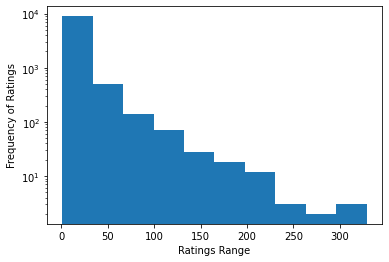

<Figure size 432x288 with 0 Axes>

In [15]:
# add your solution here
import matplotlib.pyplot as plt
plt.hist(groupingCountSeries['rating'],log = True)
plt.xlabel("Ratings Range")
plt.ylabel("Frequency of Ratings")
plt.show()
plt.savefig('distribution of movie range.png')
# groupingCountSeries['rating']


## 6. Find the names of *all* of the movies that have the highest *average* ratings?

You should return a dataframe containing the ids and names of the movies, their average ratings, and the number of ratings. NB: You may need to analyse this dataframe further to answer the questions in the quiz.

Hints:
 - Try a [groupby()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html). Once you have a Series with columns [movieId, meanRating], identify the highest value of meanRating. You can then merge this with the movies_df.
 - If the column we are trying to merge on is an index, we can use  `left_index=True` or `right_index=True` in the [pd.merge()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.merge.html).


In [16]:
# add your solution here
mean_rating = ratings_df[["movieId", "rating"]].groupby(["movieId"]).agg([np.mean]) #mean ratings 

#DF for average rating and number of ratings
rating_stats  = pd.merge(
    groupingCountSeries,
    mean_rating, 
    left_index=True,right_on = 'movieId')

#DF for highest movie ratings

highest_ratings = pd.merge(
    movies_df[['movieId','title']],
    rating_stats[rating_stats[('rating', 'mean')] == rating_stats[('rating', 'mean')].max()],
    right_index=True,left_on = 'movieId')
display(highest_ratings)

/usr/local/lib/python3.7/dist-packages/pandas/core/reshape/merge.py:643: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,movieId,title,rating,"(rating, mean)"
48,m53,Lamerica (1994),2,5.0
87,m99,Heidi Fleiss: Hollywood Madam (1995),2,5.0
121,m148,"Awfully Big Adventure, An (1995)",1,5.0
405,m467,Live Nude Girls (1995),1,5.0
432,m495,In the Realm of the Senses (Ai no corrida) (1976),1,5.0
...,...,...,...,...
9611,m176601,Black Mirror,1,5.0
9633,m179133,Loving Vincent (2017),1,5.0
9634,m179135,Blue Planet II (2017),1,5.0
9688,m184245,De platte jungle (1978),1,5.0


In [36]:
highest_ratings[highest_ratings['movieId']=='m6442']

,movieId,title,rating,"(rating, mean)"
4390,m6442,Belle époque (1992),2,5.0


You can nosw answer the question in the quiz for Task 6, based on your  observations on analysing this table?

# Part C - Association Rules and Lift

I think we can do better than simply examining movie popularity. 

Lets take all of the positive ratings (4 or 5), and find the most popular pairs of movies that users have watched.

There is a lot going on there, so please take the time to break it down to understand what it does.

NB: In this code, we perform a "self-join" on a dataframe. If this is unfamiliar, you can read more at:
 - https://dfrieds.com/data-analysis/self-join-python-pandas.html
 - https://www.w3schools.com/sql/sql_join_self.asp



In [17]:
positives = ratings_df[ratings_df["rating"]>=4]

#join positives with itself on userId to get all pairs of movies watched by a given user.
pairs = pd.merge(positives, positives, on=["userId"])

#we only want A->B, not B->A. Use the timestamps to restrict the selected pairs
sequences = pairs[pairs["timestamp_x"] < pairs["timestamp_y"]] 

#lets count the frequency of each pair of movies.
paircounts = sequences[["movieId_x", "movieId_y", "userId"]].groupby(["movieId_x", "movieId_y"]).count()
# display(paircounts)
#sort by the most popular pairs.
pairswithcounts = paircounts.reset_index().rename(columns={"userId" : "count"}).sort_values(['count'], ascending=False)

#display the top most frequent pairs
pairswithcounts.head()

,movieId_x,movieId_y,count
1574483,m318,m356,104
1416644,m296,m593,92
1416033,m296,m47,91
1187221,m260,m1196,91
1575263,m318,m527,90


## 7. Display the titles of the (most popular) movie pairs from `pairswithcounts`?

You will need to analyse this dataframe to complete questions in the quiz.

Hint:
 - you will need to re-sort after a pd.merge()

In [18]:
#add your solution here

#Merge with movieid_x
merged_mid_x = pd.merge(
    pairswithcounts, 
    movies_df,
    left_on = 'movieId_x',
    right_on ='movieId')
merged_mid_x.drop(columns= 'movieId',inplace= True) #Need to drop duplicate columns

#Merge with associated movie title 

top_movie_associations = pd.merge(
    merged_mid_x, 
    movies_df,
    left_on = 'movieId_y',
    right_on ='movieId')
top_movie_associations.drop(columns= 'movieId',inplace= True)

top_movie_associations_sorted = top_movie_associations.sort_values(by="count", ascending=False) 
display(top_movie_associations_sorted.head())
# display(top_movie_associations.head())

,movieId_x,movieId_y,count,title_x,genres_x,title_y,genres_y
0,m318,m356,104,"Shawshank Redemption, The (1994)",Crime|Drama,Forrest Gump (1994),Comedy|Drama|Romance|War
5993,m296,m593,92,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
22257,m260,m1196,91,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
17759,m296,m47,91,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
2122,m318,m527,90,"Shawshank Redemption, The (1994)",Crime|Drama,Schindler's List (1993),Drama|War


In [37]:
top_movie_associations[top_movie_associations['count']==74]

,movieId_x,movieId_y,count,title_x,genres_x,title_y,genres_y
78329,m858,m1221,74,"Godfather, The (1972)",Crime|Drama,"Godfather: Part II, The (1974)",Crime|Drama


## 8. Calculate Lift (see Lecture 3) for all pairs in `pairwithcounts`.  

Your target dataframe should have columns: 
 - movieId_x	movieId_y	
 - count - count of movies x & y occurring in a profile	
 - ratingCount_x	ratingCount_y	- how many times these movies appeared in total.
 - lift	- your calculated lift.
 - title_x, title_y, genre_x and genre_y - metadata about the films, so you know if you have success. 

Hints: 
 - You will need to join pairswithcounts with a dataframe containing rating counts of individual movies. A calculated column will be needed. See https://pandas.pydata.org/docs/getting_started/intro_tutorials/05_add_columns.html or https://stackoverflow.com/a/12377083/9989050 for hints on how to achieve that.
 - My solution had duplicated columns. I used this trick https://stackoverflow.com/a/40435354/9989050 to get rid of them.
 - It might be useful to [sort](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sort_values.html) your dataframe.

Below I provide the highest lift movies for you to check your solution.


In [19]:
# lets count the frequency for  positive ratings of each movies.
rating_counts = positives[['movieId','rating']].groupby(["movieId"]).count()

# sort by the most popular pairs.
rating_counts = rating_counts.reset_index().rename(columns={"rating" : "rating count"})

#Merge ratings with x 
merged_ratings_x = pd.merge(
    pairswithcounts,
    rating_counts,
    left_on = 'movieId_x',
    right_on ='movieId')

merged_ratings_x.drop(columns= 'movieId',inplace= True)
# display(merged_ratings_x)

#Merge ratings with y 

merged_ratings_all = pd.merge(
    merged_ratings_x, 
    rating_counts,
    left_on = 'movieId_y',
    right_on ='movieId')
merged_ratings_all.drop(columns= 'movieId',inplace= True)
# display(merged_ratings_all)

#merge movie title and genre with midx
prototype_1 = pd.merge(
    merged_ratings_all, 
    movies_df,
    left_on = 'movieId_x',
    right_on ='movieId')
prototype_1.drop(columns= 'movieId',inplace= True)

#merge movie title and genre with midy
movie_recommender = pd.merge(
    prototype_1, 
    movies_df,
    left_on = 'movieId_y',
    right_on ='movieId')
movie_recommender.drop(columns= 'movieId',inplace= True)

#calculate and sort with lift
movie_recommender['lift'] = ((movie_recommender['count']/len(ratings_df))/((movie_recommender['rating count_x']/len(ratings_df))*(movie_recommender['rating count_y']/len(ratings_df)))).round(2)
movie_recommender.sort_values(by="lift", ascending=False,inplace= True)

movie_recommender

,movieId_x,movieId_y,count,rating count_x,rating count_y,title_x,genres_x,title_y,genres_y,lift
3533035,m43836,m1703,1,1,1,"Pink Panther, The (2006)",Adventure|Comedy|Crime,For Richer or Poorer (1997),Comedy,100836.00
3223276,m97168,m128991,1,1,1,Marley (2012),Documentary,Johnny Express (2014),Animation|Comedy|Sci-Fi,100836.00
2485341,m66544,m79006,1,1,1,Nuremberg (2000),Drama|War,Empire of Dreams: The Story of the 'Star Wars'...,Documentary,100836.00
2485340,m76060,m79006,1,1,1,"Slammin' Salmon, The (2009)",Comedy,Empire of Dreams: The Story of the 'Star Wars'...,Documentary,100836.00
2485339,m27369,m79006,1,1,1,Daria: Is It Fall Yet? (2000),Animation|Comedy,Empire of Dreams: The Story of the 'Star Wars'...,Documentary,100836.00
...,...,...,...,...,...,...,...,...,...,...
10930,m329,m296,1,42,244,Star Trek: Generations (1994),Adventure|Drama|Sci-Fi,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,9.84
1189641,m2959,m349,1,179,58,Fight Club (1999),Action|Crime|Drama|Thriller,Clear and Present Danger (1994),Action|Crime|Drama|Thriller,9.71
3114754,m80463,m318,1,38,274,"Social Network, The (2010)",Drama,"Shawshank Redemption, The (1994)",Crime|Drama,9.68
15623,m454,m2571,1,48,222,"Firm, The (1993)",Drama|Thriller,"Matrix, The (1999)",Action|Sci-Fi|Thriller,9.46


In [38]:
movie_recommender[(movie_recommender['movieId_x']=='m1475') & (movie_recommender['movieId_y']=='m2024')] 

,movieId_x,movieId_y,count,rating count_x,rating count_y,title_x,genres_x,title_y,genres_y,lift
3197672,m1475,m2024,1,1,1,Kama Sutra: A Tale of Love (1996),Romance,"Rapture, The (1991)",Drama|Mystery,100836.0


In [39]:
movie_recommender[(movie_recommender['movieId_x']=='m91500') & (movie_recommender['movieId_y']=='m106487')] 

,movieId_x,movieId_y,count,rating count_x,rating count_y,title_x,genres_x,title_y,genres_y,lift
1066026,m91500,m106487,10,24,14,The Hunger Games (2012),Action|Adventure|Drama|Sci-Fi|Thriller,The Hunger Games: Catching Fire (2013),Action|Adventure|Sci-Fi|IMAX,3001.07


If your solution is correct, you will see the highest lift movie pairs. 
Lets check them - do the highest lift movies pairs make sense? e.g. "Pink Panther, The (2006)" (Adventure|Comedy|Crime) with	"For Richer or Poorer (1997)" (Comedy). 

It should be clear that these lift pairs do not have high support. 

## 9 - Support Thresholds

Removing movie pairs with support count $< 10$.

I got the "The Hunger Games (2012)" paired with "The Hunger Games: Mockingjay - Part 1 (2014)" as the movie pair with the highest lift. This seems a good pairing! 

So in essence, we can use lift to identify highly co-occurring movie pairs without resorting to any collaborative notions.

Keep this dataframe around - you will need it to answer the questions for Task 9 in the quiz.

In [20]:
# add your solution here
movie_recommender_support = movie_recommender[movie_recommender['count']>=10].sort_values(by=['lift'], ascending=False)
movie_recommender_support

,movieId_x,movieId_y,count,rating count_x,rating count_y,title_x,genres_x,title_y,genres_y,lift
1081107,m91500,m116823,11,24,15,The Hunger Games (2012),Action|Adventure|Drama|Sci-Fi|Thriller,The Hunger Games: Mockingjay - Part 1 (2014),Adventure|Sci-Fi|Thriller,3081.10
1066026,m91500,m106487,10,24,14,The Hunger Games (2012),Action|Adventure|Drama|Sci-Fi|Thriller,The Hunger Games: Catching Fire (2013),Action|Adventure|Sci-Fi|IMAX,3001.07
595539,m115713,m139385,10,20,19,Ex Machina (2015),Drama|Sci-Fi|Thriller,The Revenant (2015),Adventure|Drama,2653.58
768411,m91658,m67255,10,24,19,"Girl with the Dragon Tattoo, The (2011)",Drama|Thriller,"Girl with the Dragon Tattoo, The (Män som hata...",Crime|Drama|Mystery|Thriller,2211.32
892671,m34162,m8807,10,25,19,Wedding Crashers (2005),Comedy|Romance,Harold and Kumar Go to White Castle (2004),Adventure|Comedy,2122.86
...,...,...,...,...,...,...,...,...,...,...
15371,m457,m2571,13,137,222,"Fugitive, The (1993)",Thriller,"Matrix, The (1999)",Action|Sci-Fi|Thriller,43.10
3114554,m1206,m318,10,86,274,"Clockwork Orange, A (1971)",Crime|Drama|Sci-Fi|Thriller,"Shawshank Redemption, The (1994)",Crime|Drama,42.79
3114542,m364,m318,13,115,274,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,"Shawshank Redemption, The (1994)",Crime|Drama,41.60
10757,m457,m296,13,137,244,"Fugitive, The (1993)",Thriller,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,39.21


In [40]:
movie_recommender_support[movie_recommender_support['movieId_x']=='m110']

,movieId_x,movieId_y,count,rating count_x,rating count_y,title_x,genres_x,title_y,genres_y,lift
1260795,m110,m2403,12,166,14,Braveheart (1995),Action|Drama|War,First Blood (Rambo: First Blood) (1982),Action|Adventure|Drama|Thriller,520.67
716882,m110,m151,18,166,22,Braveheart (1995),Action|Drama|War,Rob Roy (1995),Action|Drama|Romance|War,497.00
852792,m110,m5630,10,166,15,Braveheart (1995),Action|Drama|War,Red Dragon (2002),Crime|Mystery|Thriller,404.96
475353,m110,m266,20,166,31,Braveheart (1995),Action|Drama|War,Legends of the Fall (1994),Drama|Romance|War|Western,391.90
1102410,m110,m552,12,166,19,Braveheart (1995),Action|Drama|War,"Three Musketeers, The (1993)",Action|Adventure|Comedy|Romance,383.65
...,...,...,...,...,...,...,...,...,...,...
92766,m110,m4973,12,166,95,Braveheart (1995),Action|Drama|War,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,76.73
20029,m110,m260,25,166,201,Braveheart (1995),Action|Drama|War,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,75.55
6002,m110,m593,27,166,225,Braveheart (1995),Action|Drama|War,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,72.89
33275,m110,m58559,13,166,112,Braveheart (1995),Action|Drama|War,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,70.51


In [41]:
movie_recommender_support[(movie_recommender_support['movieId_x']=='m364') & (movie_recommender_support['movieId_y']=='m362') ]

,movieId_x,movieId_y,count,rating count_x,rating count_y,title_x,genres_x,title_y,genres_y,lift
962510,m364,m362,10,115,17,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,"Jungle Book, The (1994)",Adventure|Children|Romance,515.79
